## 🔒 Persistence and ❌ False Tolerance in LangGraph

LangGraph supports **persistence**, which means it can **save and reload the graph’s state**. This is useful for:

- Resuming long workflows
- Recovering from crashes or API failures
- Avoiding recomputation of already-completed nodes

### ✅ What Is Persistence?

Persistence saves:
- The state (data)
- The execution progress (which node ran last)

This allows you to **restart from the last successful step** instead of beginning from scratch.

---

### ❗ What Is False Tolerance?

**False tolerance** happens when:
- A node (like an LLM) is **non-deterministic** (can give different outputs each time)
- You **resume execution** assuming old outputs are still valid
- But the actual output might have changed (and you didn’t notice)

LangGraph **thinks** everything is fine — but you’re actually running the wrong logic.

---

### 🧠 Simple Example

1. A node generates a tweet:  
   `"Being an adult is basically just googling 'how to fix your life' every Monday."`

2. The tweet is approved by an evaluator.

3. LangGraph **persists** the state (it saves the tweet and that it was approved).

4. The system crashes.

5. You **resume the workflow**.

6. But... the tweet **was not stored properly**, and the generator runs again.

7. This time it generates:  
   `"My Fitbit just congratulated me for checking the fridge 14 times today."`

8. LangGraph still thinks the tweet is approved — even though it’s now a **different** tweet.

> 🎯 You now have a **false sense of correctness**.  
> The graph *tolerated* the resume, but it’s no longer consistent.

---

### 🔄 Why Does This Happen?

LangGraph assumes that your nodes are **deterministic**, meaning:

> For the same input, the output will always be the same.

But LLMs (and some tools) are not deterministic unless:
- You fix the random seed
- Or cache/log their output explicitly

---

### ✅ Best Practices to Avoid False Tolerance

- **Log or store outputs** (especially from LLMs) during execution
- **Avoid re-running** non-deterministic nodes after a crash unless needed
- Use a **persistent backend** (e.g. Redis, file system, database)
- Consider using **caching** for LLMs (e.g. via LangChain's cache)

---

### 📝 TL;DR

| Term             | Meaning |
|------------------|---------|
| Persistence      | Save & resume workflows |
| False Tolerance  | Thinking the state is valid when it’s actually out of sync |
| Deterministic    | Always gives same output for same input |
| Non-deterministic| May return different output every time (like LLMs) |

Make sure your graph either:
- Replays nodes correctly
- Or stores their outputs reliably


In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [11]:
# load_dotenv()

# llm = ChatOpenAI()

In [12]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.2")

In [13]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [14]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [15]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [16]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

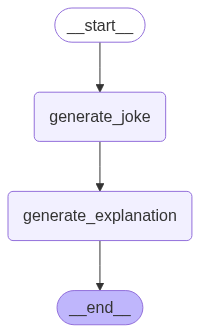

In [17]:
workflow

In [18]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.',
 'explanation': 'This joke is a play on words, using a common idiomatic expression to create a pun.\n\nThe phrase "feeling crusty" typically means being irritable or grumpy. However, in this joke, it\'s used as a literal description of the pizza\'s condition. A crust is the outer layer of a pizza, so the punchline implies that the pizza is feeling cranky because it has a crust - both physically and figuratively.\n\nThe humor comes from the unexpected twist on the usual meaning of "crusty" and the clever wordplay, which creates a pun that connects the literal and figurative meanings of the phrase. It\'s a lighthearted and silly joke that brings a smile to the listener\'s face!'}

In [19]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship!',
 'explanation': 'This is a classic play on words, and here\'s why it\'s funny:\n\nThe joke relies on a double meaning of the word "tangled". In one sense, when we talk about being "tangled" up in a relationship, we mean that the person is getting caught up in a complicated or entangled emotional situation. This is often used to describe a romantic relationship where two people are deeply invested and may have difficulty separating themselves.\n\nHowever, when we talk about spaghetti, we also use this word literally - it\'s a type of pasta that is notoriously difficult to untangle because it becomes knotted and twisted together. So, in the context of the joke, "getting tangled up" means being wrapped up or entangled with another person, much like how spaghetti can become knotted.\n\nThe punchline "afraid of getting tangled up in a relationship" is

In [20]:
# this is the final state value of thread 1 mean only last state value
workflow.get_state(config1) 

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.', 'explanation': 'This joke is a play on words, using a common idiomatic expression to create a pun.\n\nThe phrase "feeling crusty" typically means being irritable or grumpy. However, in this joke, it\'s used as a literal description of the pizza\'s condition. A crust is the outer layer of a pizza, so the punchline implies that the pizza is feeling cranky because it has a crust - both physically and figuratively.\n\nThe humor comes from the unexpected twist on the usual meaning of "crusty" and the clever wordplay, which creates a pun that connects the literal and figurative meanings of the phrase. It\'s a lighthearted and silly joke that brings a smile to the listener\'s face!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070a07-e89b-629f-8002-4f2747843c1f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_

In [21]:
# this is the final state value along with intermidiate state also this
# bassically mean for all state
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.', 'explanation': 'This joke is a play on words, using a common idiomatic expression to create a pun.\n\nThe phrase "feeling crusty" typically means being irritable or grumpy. However, in this joke, it\'s used as a literal description of the pizza\'s condition. A crust is the outer layer of a pizza, so the punchline implies that the pizza is feeling cranky because it has a crust - both physically and figuratively.\n\nThe humor comes from the unexpected twist on the usual meaning of "crusty" and the clever wordplay, which creates a pun that connects the literal and figurative meanings of the phrase. It\'s a lighthearted and silly joke that brings a smile to the listener\'s face!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070a07-e89b-629f-8002-4f2747843c1f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created

In [22]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship!', 'explanation': 'This is a classic play on words, and here\'s why it\'s funny:\n\nThe joke relies on a double meaning of the word "tangled". In one sense, when we talk about being "tangled" up in a relationship, we mean that the person is getting caught up in a complicated or entangled emotional situation. This is often used to describe a romantic relationship where two people are deeply invested and may have difficulty separating themselves.\n\nHowever, when we talk about spaghetti, we also use this word literally - it\'s a type of pasta that is notoriously difficult to untangle because it becomes knotted and twisted together. So, in the context of the joke, "getting tangled up" means being wrapped up or entangled with another person, much like how spaghetti can become knotted.\n\nThe punchline "afraid of getting tangled up in

In [23]:
# see all the previous states and checkpoints associated with a thread
# giving you the full timeline of how the state has evolved.
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship!', 'explanation': 'This is a classic play on words, and here\'s why it\'s funny:\n\nThe joke relies on a double meaning of the word "tangled". In one sense, when we talk about being "tangled" up in a relationship, we mean that the person is getting caught up in a complicated or entangled emotional situation. This is often used to describe a romantic relationship where two people are deeply invested and may have difficulty separating themselves.\n\nHowever, when we talk about spaghetti, we also use this word literally - it\'s a type of pasta that is notoriously difficult to untangle because it becomes knotted and twisted together. So, in the context of the joke, "getting tangled up" means being wrapped up or entangled with another person, much like how spaghetti can become knotted.\n\nThe punchline "afraid of getting tangled up i

### Time Travel
#### What Is Time Travel?

In LangGraph, **Time Travel** means you can **rewind to a previous state** in the graph's execution history and **resume from that exact point**, as if you were back in time.

LangGraph enables this by **persisting a versioned history** of state transitions at each step.

---

### 🔄 Why Use Time Travel?

- **Debugging**: Inspect what the state looked like before an error or unexpected behavior.
- **Replaying**: Retry from a known good point instead of restarting the whole workflow.
- **Auditing**: Trace and analyze decisions made by the graph over time.

---

### 🧠 Example

You're running a workflow that generates and evaluates tweets.

#### Iteration 1:
- Tweet: `"Gym is just clubbing with pain"`
- Evaluation: `"needs_improvement"`

#### Iteration 2:
- Tweet: `"Every Monday is a sequel nobody asked for"`
- Evaluation: `"approved"`

LangGraph automatically saves state at each step.

With **Time Travel**, you can:
- Rewind to **Iteration 1**
- View or change the tweet
- Re-run the evaluation or optimization from that point

---

### 🧭 Time Travel vs Replay

| Feature        | Description                                              |
|----------------|----------------------------------------------------------|
| **Replay**     | Re-runs logic from a given point                         |
| **Time Travel**| Fully restores a previous state for inspection or replay |

---

### 🛠 How It Works (Conceptually)

LangGraph's persistent backends (e.g., file system, Redis, database) store:
- The full state at each node
- The history of transitions
- Metadata for version tracking

You can then:
1. Load a previous state checkpoint
2. Set it as your current state
3. Continue execution from there

---

### ✅ Summary

| Concept       | Explanation |
|---------------|-------------|
| **Time Travel**   | Jump back to a previous step in execution history |
| **Uses**          | Debugging, experimentation, auditing |
| **Key Benefit**   | Restore and resume without re-running the entire graph |
| **Enabled By**    | LangGraph's state persistence mechanism |

In [28]:
# see all the previous states and checkpoints associated with a thread
# giving you the full timeline of how the state has evolved.
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.', 'explanation': 'A classic play on words!\n\nThe joke relies on a pun, which is a type of wordplay that exploits multiple meanings of a word or phrase. In this case, the punchline "feeling crusty" has a double meaning.\n\nOn the surface, "crusty" refers to the outer layer of bread that is typically hard and dry on a pizza. However, it also means being grumpy or irritable, like someone with a bad temper.\n\nThe joke sets up the expectation that the pizza is in a bad mood, but instead of providing a conventional reason (e.g., "it was having a rough day" or "it was tired"), it subverts our expectations by using a wordplay that connects the pizza\'s condition to its emotional state. The punchline cleverly links the crusty texture of the pizza with its grumpy demeanor, creating a humorous connection between the physical property and the emotional state.\n\nThe joke requires 

In [26]:
# retrieves a specific checkpoint of the workflow state
workflow.get_state({
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f070a06-aa2f-676c-8000-1ea759df9319"
    }
})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f070a06-aa2f-676c-8000-1ea759df9319'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-08-03T19:31:13.462856+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070a06-aa2b-6d55-bfff-efba03657e52'}}, tasks=(PregelTask(id='8c6fac44-c02e-cf19-8a90-fdbe90cd1623', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.'}),), interrupts=())

In [27]:
# resume execution from that past checkpoint, effectively continuing the graph
workflow.invoke(None, {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f070a06-aa2f-676c-8000-1ea759df9319"
    }
})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.',
 'explanation': 'A classic play on words!\n\nThe joke relies on a pun, which is a type of wordplay that exploits multiple meanings of a word or phrase. In this case, the punchline "feeling crusty" has a double meaning.\n\nOn the surface, "crusty" refers to the outer layer of bread that is typically hard and dry on a pizza. However, it also means being grumpy or irritable, like someone with a bad temper.\n\nThe joke sets up the expectation that the pizza is in a bad mood, but instead of providing a conventional reason (e.g., "it was having a rough day" or "it was tired"), it subverts our expectations by using a wordplay that connects the pizza\'s condition to its emotional state. The punchline cleverly links the crusty texture of the pizza with its grumpy demeanor, creating a humorous connection between the physical property and the emotional state.\n\nThe joke requires a brief moment of me

In [29]:
# see all the previous states and checkpoints associated with a thread
# giving you the full timeline of how the state has evolved.
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.', 'explanation': 'A classic play on words!\n\nThe joke relies on a pun, which is a type of wordplay that exploits multiple meanings of a word or phrase. In this case, the punchline "feeling crusty" has a double meaning.\n\nOn the surface, "crusty" refers to the outer layer of bread that is typically hard and dry on a pizza. However, it also means being grumpy or irritable, like someone with a bad temper.\n\nThe joke sets up the expectation that the pizza is in a bad mood, but instead of providing a conventional reason (e.g., "it was having a rough day" or "it was tired"), it subverts our expectations by using a wordplay that connects the pizza\'s condition to its emotional state. The punchline cleverly links the crusty texture of the pizza with its grumpy demeanor, creating a humorous connection between the physical property and the emotional state.\n\nThe joke requires 

In [ ]:
# kj;askd

### Updating State

In [30]:
# modifies the state at a specific checkpoint (checkpoint_id), changing or 
# injecting new values ('topic': 'samosa' in this case)
workflow.update_state(
    {
        "configurable": {
            "thread_id": "1",
            "checkpoint_id": "1f070a06-aa2f-676c-8000-1ea759df9319",
            "checkpoint_ns": ""
        }
    },
    {"topic": "samosa"}
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f070a14-cf6b-6084-8001-c00f76c9da23'}}

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070a14-cf6b-6084-8001-c00f76c9da23'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-08-03T19:37:33.176621+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070a06-aa2f-676c-8000-1ea759df9319'}}, tasks=(PregelTask(id='59be2cce-6586-ea63-8521-35cdcc30dd43', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling crusty.', 'explanation': 'A classic play on words!\n\nThe joke relies on a pun, which is a type of wordplay that exploits multiple meanings of a word or phrase. In this case, the punchline "feeling crusty" has a double meaning.\n\nOn the surface, "crusty" refers to the o

In [32]:
# resumes execution from the modified checkpoint.
# Since the previous state was updated (e.g. 'topic': 'samosa'), the resumed 
# execution now continues with the new value in place.
workflow.invoke(
    None,
    {
        "configurable": {
            "thread_id": "1",
            "checkpoint_id": "1f070a14-cf6b-6084-8001-c00f76c9da23"
        }
    }
)

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling crumby about its life! (get it? crumby like the crunchy outside of a samosa)',
 'explanation': 'A delightful pun!\n\nThe joke relies on a clever play on words, specifically the double meaning of the word "crumby". In this case:\n\n1. "Crumby" refers to the crispy outer shell of a traditional Indian samosa, which is often described as crunchy or flaky.\n2. The phrase "feeling crumby" is an idiomatic expression that means feeling down, unhappy, or struggling with one\'s emotions.\n\nThe joke sets up a expectation that the punchline will be a straightforward answer to why the samosa went to therapy. However, it subverts this expectation by using the second meaning of "crumby", creating a clever connection between the physical characteristics of the samosa and its emotional state. The humor lies in the unexpected twist, which requires a split-second recognition of the wordplay to fully appreciate the 

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it was feeling crumby about its life! (get it? crumby like the crunchy outside of a samosa)', 'explanation': 'A delightful pun!\n\nThe joke relies on a clever play on words, specifically the double meaning of the word "crumby". In this case:\n\n1. "Crumby" refers to the crispy outer shell of a traditional Indian samosa, which is often described as crunchy or flaky.\n2. The phrase "feeling crumby" is an idiomatic expression that means feeling down, unhappy, or struggling with one\'s emotions.\n\nThe joke sets up a expectation that the punchline will be a straightforward answer to why the samosa went to therapy. However, it subverts this expectation by using the second meaning of "crumby", creating a clever connection between the physical characteristics of the samosa and its emotional state. The humor lies in the unexpected twist, which requires a split-second recognition of the wordplay to f

### Fault Tolerance

#### ❗ What Is False Tolerance?

**False tolerance** happens when:
- A node (like an LLM) is **non-deterministic** (can give different outputs each time)
- You **resume execution** assuming old outputs are still valid
- But the actual output might have changed (and you didn’t notice)

LangGraph **thinks** everything is fine — but you’re actually running the wrong logic.


In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print(" Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print(" Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(60)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print(" Step 3 executed")
    return {"done": True}

In [ ]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
# starts a new execution of the workflow passing in a fresh input state ({"input": "start"}) to the graph.
try:
    print("▶ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print(" Kernel manually interrupted (crash simulated).")

▶ Running graph: Please manually interrupt during Step 2...
 Step 1 executed
 Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [ ]:
# 6. Re-run to show fault-tolerant resume  an existing execution of the workflow
# "None" as the first argument means: "don’t pass a new initial input."
print("\n Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n Final State:", final_state)

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[]